In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./datasets/Coleta_Pardas.csv")

In [3]:
df

,Name,Original_Text,Cor,Conclusao
0,Adilson Pereira Dos Santos,\nEXCELENTÍSSIMO(A) SENHOR(A) DOUTOR(A) JUIZ(A...,Parda,NaN
1,Adilson Pereira Dos Santos,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO ...,Parda,NaN
2,Adilson Pereira Dos Santos,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO ...,Parda,NaN
3,Adilson Pereira Dos Santos,EXMO. SENHOR DOUTOR JUIZ DE DIREITO DO a JUIZ...,Parda,NaN
4,Adilson Pereira Dos Santos,2021 - Ano Internacional para a Eliminação do...,Parda,NaN
...,...,...,...,...
366,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
367,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
368,Wilson Jose De Araujo,AO JUÍZO DE DIREITO DA VARA DO JUIZADO ESPECI...,Parda,NaN
369,Wilson Jose De Araujo,\nEXCELENTÍSSIMA SENHORA DOUTORA JUÍZA DE DIRE...,Parda,PERDIDO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           371 non-null    object
 1   Original_Text  371 non-null    object
 2   Cor            371 non-null    object
 3   Conclusao      106 non-null    object
dtypes: object(4)
memory usage: 11.7+ KB


In [5]:
situacao = df["Conclusao"].value_counts().reset_index()

In [6]:
situacao

,Conclusao,count
0,PERDIDO,51
1,GANHO,29
2,AMBIGUO,26


In [7]:
situacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Conclusao  3 non-null      object
 1   count      3 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


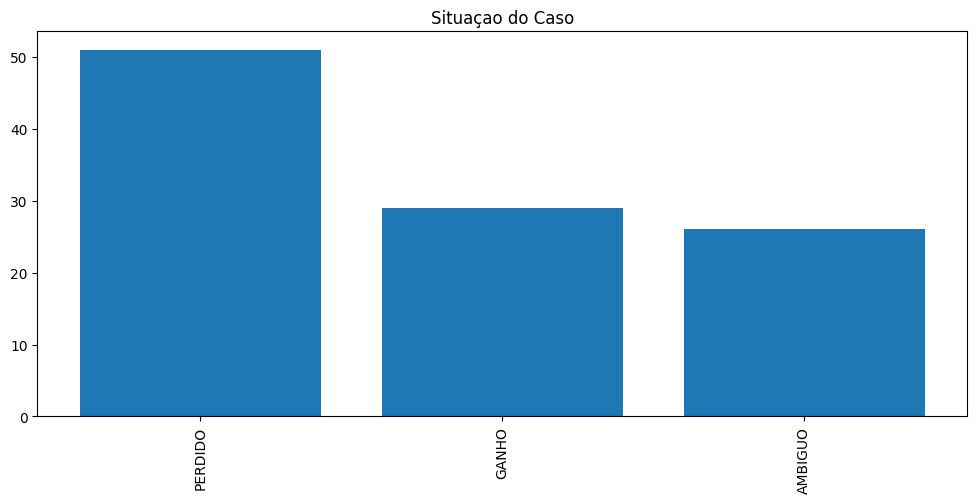

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.bar(situacao["Conclusao"], height=situacao["count"],)
plt.xticks(rotation=90)
# plt.bar()
ax.set_title("Situaçao do Caso")
plt.show()

In [9]:
from nltk.stem import PorterStemmer
import nltk
from nltk.corpus import stopwords

# stopwords = nltk.download('stopwords')
stemmer = PorterStemmer()

## TF - IDF


In [10]:
df = df.dropna(subset="Conclusao")

In [11]:

from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,2) )
X = tf_idf.fit_transform(df["Original_Text"])
vocab = tf_idf.get_feature_names_out()

In [12]:
vocab

array(['00', '00 00', '00 000', ..., 'üéber rod', 'üíj', 'üíj vh'],
      dtype=object)

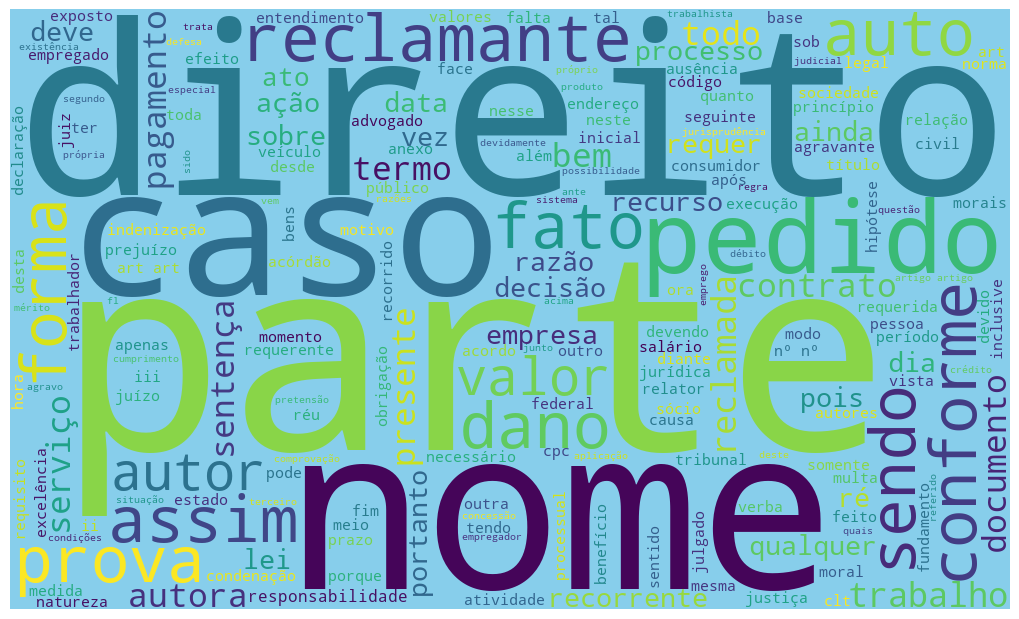

In [13]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud
vocab = ' '.join(vocab)

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='skyblue',
    min_font_size=10).generate(vocab)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [14]:
X

<106x110099 sparse matrix of type '<class 'numpy.float64'>'
	with 250777 stored elements in Compressed Sparse Row format>

In [15]:
df["Conclusao"]

20     AMBIGUO
28       GANHO
29       GANHO
30       GANHO
31       GANHO
        ...   
364    AMBIGUO
365    PERDIDO
366    AMBIGUO
367    AMBIGUO
369    PERDIDO
Name: Conclusao, Length: 106, dtype: object

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Conclusao"] = le.fit_transform(df["Conclusao"])

C:\Users\alexa\AppData\Local\Temp\ipykernel_5716\3074434007.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Conclusao"] = le.fit_transform(df["Conclusao"])


In [17]:
df["Conclusao"]

20     0
28     1
29     1
30     1
31     1
      ..
364    0
365    2
366    0
367    0
369    2
Name: Conclusao, Length: 106, dtype: int32

In [18]:
from sklearn.decomposition import PCA, TruncatedSVD

pca = TruncatedSVD(n_components=3)

In [19]:
# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['Original_Text','Cor', "Conclusao"])
df_pca = df_pca.dropna(subset=["Conclusao"])



In [20]:
y = df["Conclusao"].reset_index(drop=True)

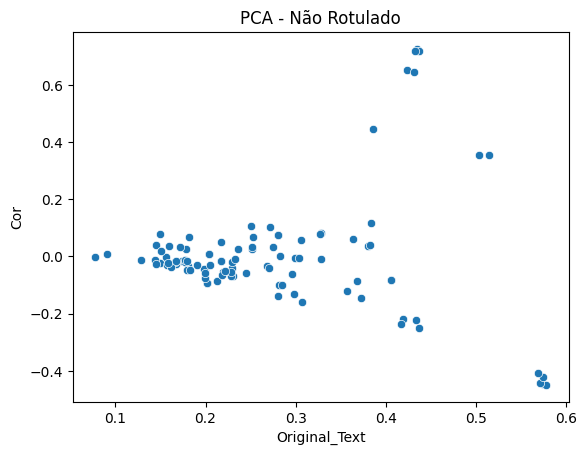

In [21]:



# Visualize the transformed data
sns.scatterplot(x='Original_Text', y="Cor", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

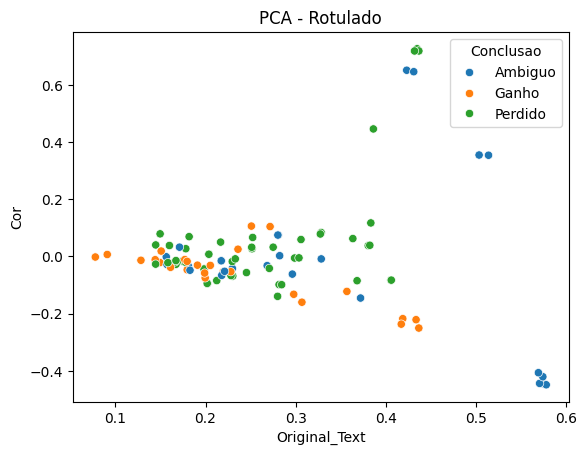

In [22]:
y_map = {0: 'Ambiguo', 1: "Ganho", 2: "Perdido"}


y = y.map(y_map)


df_pca["Conclusao"] = y

# Visualize the transformed data

sns.scatterplot(x='Original_Text', y="Cor", hue="Conclusao", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

# Treinar Modelo


In [23]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [24]:
X_train

<84x110099 sparse matrix of type '<class 'numpy.float64'>'
	with 206031 stored elements in Compressed Sparse Row format>

In [25]:
# Creating a function to display model results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Ambiguo", "Ganho", "Perdido"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

# Logistic Regression


In [26]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LogisticRegression(
    random_state=42, max_iter=1000, solver="lbfgs", penalty="l2", C=1, tol=0.0001)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.45454545 0.28571429 0.71428571 0.66666667 0.80952381]
Mean F1 Score: 0.5861471861471861


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.00      0.00      0.00         6
       Ganho       1.00      0.14      0.25         7
     Perdido       0.43      1.00      0.60         9

    accuracy                           0.45        22
   macro avg       0.48      0.38      0.28        22
weighted avg       0.49      0.45      0.32        22



c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

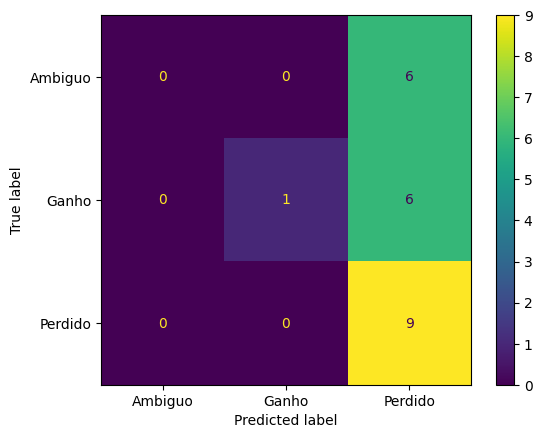

In [27]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier


In [28]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = SGDClassifier(random_state=42, alpha=0.0001, )

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.68181818 0.42857143 0.76190476 0.76190476 0.76190476]
Mean F1 Score: 0.6792207792207792


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       1.00      0.50      0.67         6
       Ganho       0.67      0.57      0.62         7
     Perdido       0.62      0.89      0.73         9

    accuracy                           0.68        22
   macro avg       0.76      0.65      0.67        22
weighted avg       0.74      0.68      0.68        22



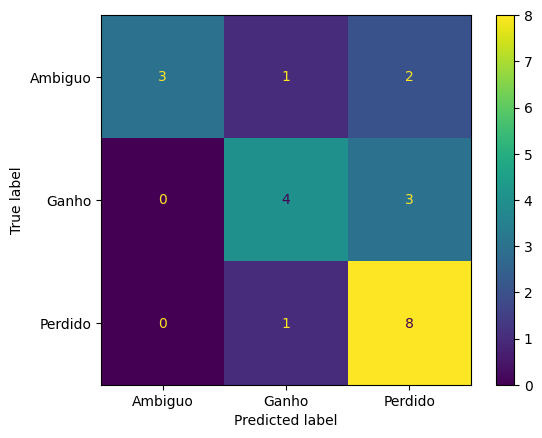

In [29]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# KNeighbors Classifier


In [30]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
# You can adjust the number of neighbors
model = KNeighborsClassifier(
    n_neighbors=1, weights="uniform", algorithm="brute", leaf_size=30, p=2)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.63636364 0.38095238 0.76190476 0.71428571 0.61904762]
Mean F1 Score: 0.6225108225108225


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.80      0.67      0.73         6
       Ganho       0.57      0.57      0.57         7
     Perdido       0.60      0.67      0.63         9

    accuracy                           0.64        22
   macro avg       0.66      0.63      0.64        22
weighted avg       0.65      0.64      0.64        22



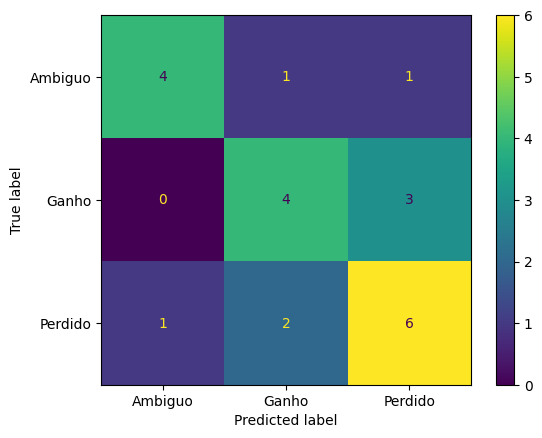

In [31]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - KNN", y_test, y_pred)

# SVC


In [32]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

K = 5

kf = KFold(n_splits=K, shuffle=True, random_state=42)


model = LinearSVC(penalty="l2", loss='squared_hinge',
                  tol=0.000001, C=10, multi_class='ovr', dual=True)


cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.63636364 0.38095238 0.80952381 0.76190476 0.76190476]
Mean F1 Score: 0.67012987012987


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       1.00      0.33      0.50         6
       Ganho       0.67      0.57      0.62         7
     Perdido       0.57      0.89      0.70         9

    accuracy                           0.64        22
   macro avg       0.75      0.60      0.60        22
weighted avg       0.72      0.64      0.62        22



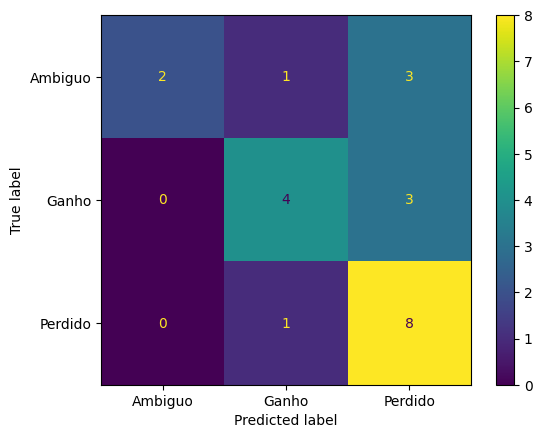

In [33]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest


In [34]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = RandomForestClassifier(
    n_estimators=100, criterion='log_loss', max_depth=None, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.59090909 0.33333333 0.80952381 0.9047619  0.76190476]
Mean F1 Score: 0.6800865800865801


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       1.00      0.33      0.50         6
       Ganho       0.67      0.29      0.40         7
     Perdido       0.53      1.00      0.69         9

    accuracy                           0.59        22
   macro avg       0.73      0.54      0.53        22
weighted avg       0.70      0.59      0.55        22



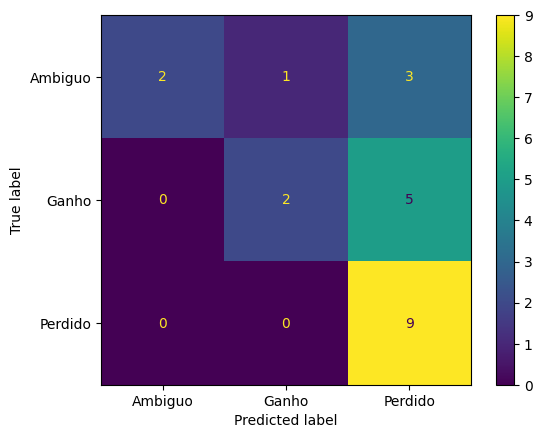

In [35]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree


Cross-Validation Results: [0.54545455 0.28571429 0.52380952 0.66666667 0.57142857]
Mean F1 Score: 0.5186147186147186


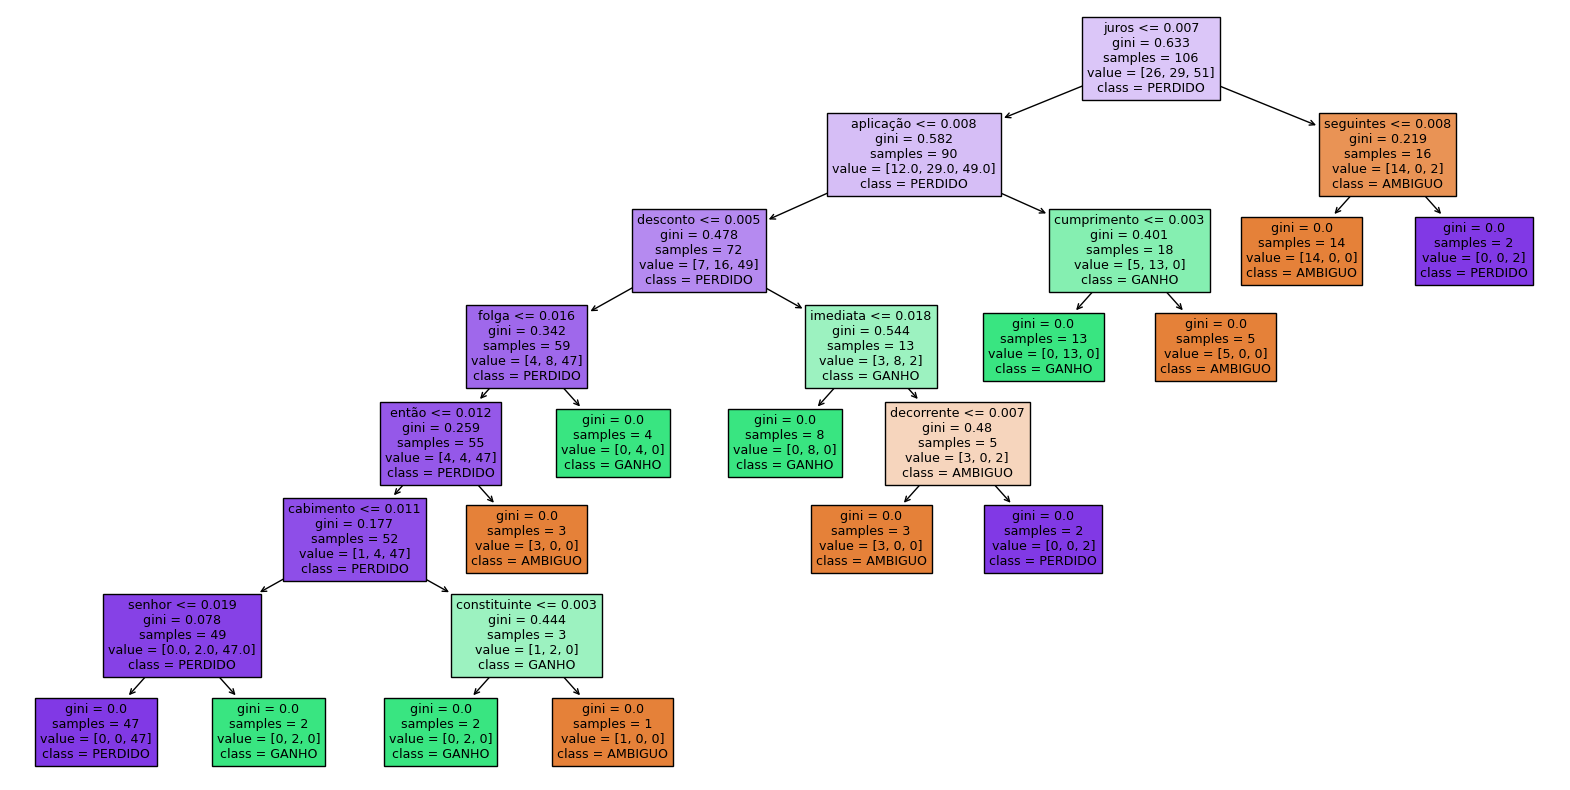

In [36]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Create the decision tree classifier
model = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')

# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

# Fit the decision tree classifier on the entire dataset
model.fit(X, y)

# Plot the decision tree
plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
plot_tree(model, feature_names=vocab.split() ,class_names=["AMBIGUO", "GANHO", "PERDIDO"], filled=True)

plt.show()
